## 数据加载、可视化与线性回归

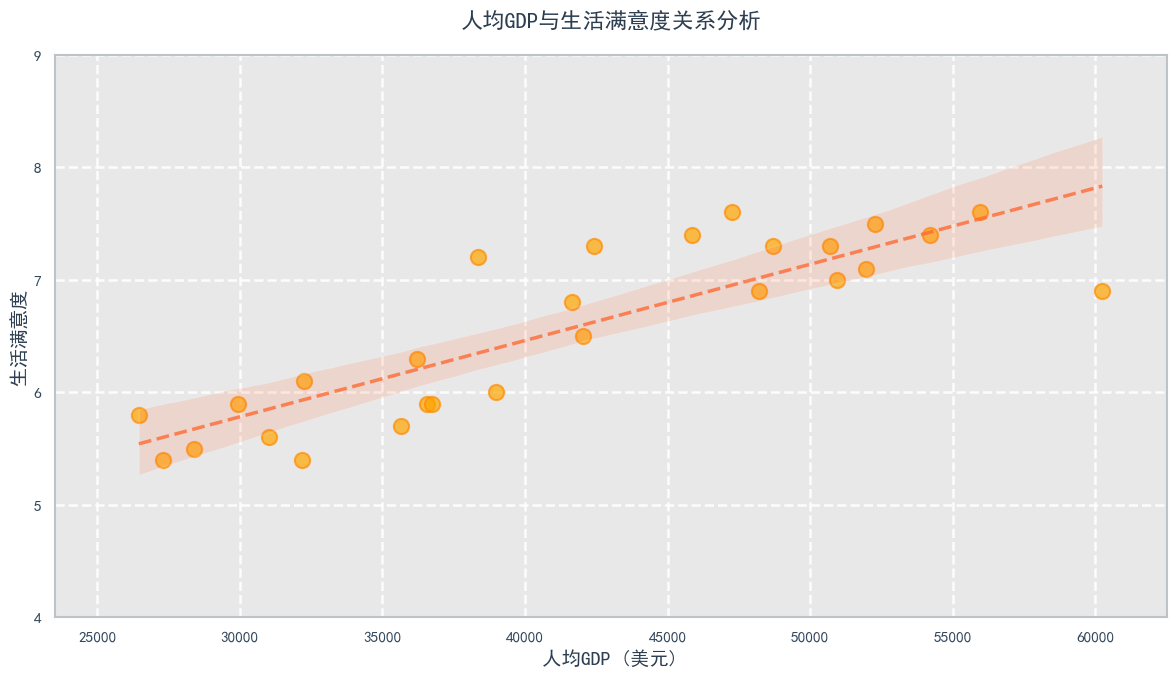

预测结果: 6.30


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression  # 导入线性回归

# 设置 Seaborn 样式
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)
sns.set_palette("husl")

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 解决负号问题

lifesat = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# 可视化数据 - 使用seaborn美化
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('#E8E8E8')  # 设置坐标轴背景为浅灰色

# 使用seaborn 绘制散点图和回归线
sns.regplot(x=lifesat["GDP per capita (USD)"],
            y=lifesat["Life satisfaction"],
            scatter_kws={
                'color': 'orange',
                's': 120,  # 散点大小
                'alpha': 0.7,
                'edgecolor': 'darkorange',
                'linewidths': 1.5
            },
            line_kws={
                'color': '#FF6B35',  # 回归线颜色
                'linewidth': 2.5,
                'linestyle': '--',
                'alpha': 0.8
            },
            ci=95,   # 95% 置信区间
            ax=ax)

# 设置中文标签
ax.set_xlabel('人均GDP (美元)', fontsize=14, fontweight='bold', color='#2C3E50')
ax.set_ylabel('生活满意度', fontsize=14, fontweight='bold', color='#2C3E50')
ax.set_title('人均GDP与生活满意度关系分析', fontsize=16, fontweight='bold',
             color='#2C3E50', pad=20)

# 设置白色虚线网格
ax.grid(True, color='white', linestyle='--', linewidth=1.8, alpha=0.9)

# 设置坐标轴范围
ax.set_xlim(23_500, 62_500)
ax.set_ylim(4, 9)

# 美化坐标轴刻度
ax.tick_params(axis='both', which='major', labelsize=11, colors='#34495E')

# 添加边框样式
for spine in ax.spines.values():
    spine.set_edgecolor('#BDC3C7')
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

# 选择线性模型（导入算法，不是创建模型！）
model = LinearRegression()

# 训练模型
model.fit(X, y)  # 真正训练，可以训练完成后进行保存，由于此时的项目比较简单，不用跑轮数，就能解决，这种模型较小，没有保存的意义

# 为塞浦路斯做预测
X_new = [[37_655.2]]  # 塞浦路斯2020年人均GDP
prediction = model.predict(X_new)     # 预测模型
print(f"预测结果: {prediction[0][0]:.2f}")  # 输出中文提示

## K近邻回归模型 (KNN)

In [4]:
# [9]: # 选择一个 3 近邻回归模型
from sklearn.neighbors import KNeighborsRegressor  # K近邻线性回归模型

model_knn = KNeighborsRegressor(n_neighbors=3)  # 取3个邻居做样本
# 这里将一个故事：在欧洲某个小镇，来了一个外乡人，这个外乡人是黑头发，黑眼睛，但是欧洲群众投票认为他就是同一个若种，那么分类上他
# 就属于这个小镇

# 训练模型
model_knn.fit(X, y)

# 为塞浦路斯做预测
prediction_knn = model_knn.predict(X_new)
print(f"K近邻回归预测结果: {prediction_knn[0][0]:.2f}") # 输出 [[6.33333333]]

K近邻回归预测结果: 6.33


In [9]:
# [12]:
oecd_bli = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\oecd_bli.csv")  # 读取OECD生活满意度数据
oecd_bli = oecd_bli[oecd_bli["INEQUALITY"]=="TOT"] # 获取总计数据，排除分群组(分维度)
oecd_bli = oecd_bli.pivot(index="Country", columns="Indicator", values="Value")
oecd_bli.head()

# [14]:
gdp_per_capita = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\gdp_per_capita.csv", delimiter='\t', encoding='latin1', na_values="n/a")
gdp_per_capita.rename(columns={"2020": "GDP per capita (USD)"}, inplace=True)
gdp_per_capita.set_index("Country", inplace=True)
gdp_per_capita.head()

KeyError: "None of ['Country'] are in the columns"

In [ ]:
# left: 左表 (OECD生活满意度数据)
# right: 右表 (人均GDP数据)
# left_index=True, right_index=True 以两表的索引(均为国家名)作为连接键
full_country_stats = pd.merge(left=oecd_bli, right=gdp_per_capita,
                              left_index=True, right_index=True)
full_country_stats.sort_values(by="GDP per capita (USD)", inplace=True)
remove_indices = [0, 1, 6, 8, 33, 34, 35]
keep_indices = list(set(range(36)) - set(remove_indices))

# 这里的逻辑似乎在原代码中被简化了，图片中直接展示了根据GDP筛选
# 下面是图片中展示的筛选逻辑：
full_country_stats = full_country_stats[["GDP per capita (USD)", "Life satisfaction"]]

full_country_stats.head()
# 为了说明过拟合的风险，在大部分图表中只使用了部分数据 (即人均GDP处于min_gdp和max_gdp之间的国家)
# 被移除的国家是那些可能会对模型产生干扰的离群点
min_gdp = 23_500
max_gdp = 62_500

country_stats = full_country_stats[(full_country_stats["GDP per capita (USD)"] >= min_gdp) &
                                   (full_country_stats["GDP per capita (USD)"] <= max_gdp)]
country_stats.head()

In [ ]:
# [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 定义图片保存函数
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join("images", fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 准备数据
sample_data = full_country_stats[["GDP per capita (USD)", "Life satisfaction"]]
sample_data.plot(kind='scatter', x="GDP per capita (USD)", y="Life satisfaction", figsize=(5,3))
plt.axis([0, 60000, 0, 10])

# 定义要坐标标注的国家及其中文位置
position_text = {
    "Hungary": (5000, 1),
    "Korea": (18000, 1.7),
    "France": (29000, 2.4),
    "Australia": (40000, 3.0),
    "United States": (52000, 3.8),
}

# 绘制散点图并标注
for country, pos_text in position_text.items():
    pos_data_x, pos_data_y = sample_data.loc[country]
    country = "U.S." if country == "United States" else country
    plt.annotate(country, xy=(pos_data_x, pos_data_y), xytext=pos_text,
            arrowprops=dict(facecolor='black', width=0.5, shrink=0.1, headwidth=5))
    plt.plot(pos_data_x, pos_data_y, "ro")

plt.xlabel("GDP per capita (USD)")
plt.show()

In [ ]:
# [28]:
import matplotlib.pyplot as plt
import numpy as np

# ... (省略重复的设置部分) ...

# 模型参数调整演示
lin1 = np.linspace(0, 60000, 1000)
plt.plot(sample_data["GDP per capita (USD)"], sample_data["Life satisfaction"], "bo")

theta0 = 4.85
theta1 = 4.91e-5
plt.plot(lin1, theta0 + theta1 * lin1, "b")

theta0 = 8
theta1 = -5e-5
plt.plot(lin1, theta0 + theta1 * lin1, "g")

theta0 = 0
theta1 = 2e-4
plt.plot(lin1, theta0 + theta1 * lin1, "r")

plt.axis([0, 60000, 0, 10])
plt.show()

In [ ]:
# [32]:
from sklearn import linear_model

lin1 = linear_model.LinearRegression()
Xsample = np.c_[sample_data["GDP per capita (USD)"]]
ysample = np.c_[sample_data["Life satisfaction"]]

lin1.fit(Xsample, ysample)

t0, t1 = lin1.intercept_[0], lin1.coef_[0][0]

print(f"截距 (theta0): {t0}")
print(f"斜率 (theta1): {t1}")

# 绘制最佳拟合线
plt.plot(sample_data["GDP per capita (USD)"], sample_data["Life satisfaction"], "bo")
plt.plot(Xsample, t0 + t1 * Xsample, "b")
plt.axis([0, 60000, 0, 10])
plt.show()

In [ ]:
cyprus_gdp_per_capita = gdp_per_capita.loc["Cyprus"]["GDP per capita (USD)"]
print(cyprus_gdp_per_capita)
# 输出: 37655.1803457421

# [41]:
cyprus_predicted_life_satisfaction = lin1.predict([[cyprus_gdp_per_capita]])[0][0]
print(cyprus_predicted_life_satisfaction)
# 输出: 6.301657...

# [45]: 绘图展示预测结果
sample_data.plot(kind='scatter', x="GDP per capita (USD)", y="Life satisfaction", figsize=(5,3), s=1)
X=np.linspace(0, 60000, 1000)
plt.plot(X, t0 + t1*X, "b")
plt.axis([0, 60000, 0, 10])
plt.text(5000, 7.5, r"$\theta_0 = 4.85$", fontsize=14, color="b")
plt.text(5000, 6.6, r"$\theta_1 = 4.91 \times 10^{-5}$", fontsize=14, color="b")

plt.plot([cyprus_gdp_per_capita, cyprus_gdp_per_capita], [0, cyprus_predicted_life_satisfaction], "r--")
plt.text(25000, 5.0, r"Prediction = 6.30", fontsize=14, color="b")
plt.plot(cyprus_gdp_per_capita, cyprus_predicted_life_satisfaction, "ro")
plt.show()

完整数据偏差分析：训练数据代表性研究

1. 读取训练数据...
   训练集包含 27 个国家

2. 读取完整数据集...
   完整数据集包含 36 个国家

3. 训练原始线性回归模型（使用训练集）...
   原始模型参数: theta0=3.75, theta1=6.78e-05
   训练数据GDP范围: $26456 - $60236

4. 识别超出训练范围的国家...
   找到 9 个国家超出训练范围

5. 开始绘制对比图表...
   - 添加国家标注...
    警告：数据中未找到国家 'Iceland'
   - 绘制原始模型预测线（蓝色虚线）...
   - 训练完整数据集模型（使用full的数据）...
   完整模型参数: theta0=5.58, theta1=2.33e-05
   - 绘制完整模型预测线（黑色实线）...
保存图片: representative_training_data_scatterplot


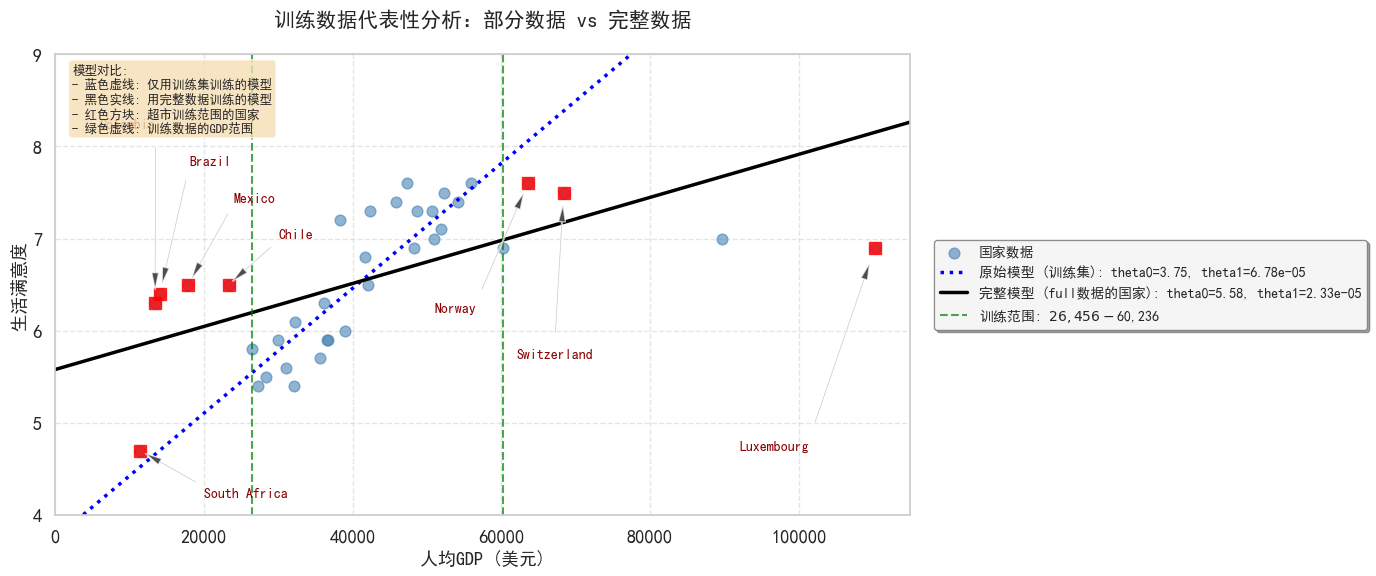


分析结果总结

训练集统计:
  - 国家数量: 27
  - GDP范围: $26,456 - $60,236
  - 模型参数: theta0=3.75, theta1=6.78e-05

完整数据集统计:
  - 国家数量: 36
  - GDP范围: $11,466 - $110,261
  - 模型参数: theta0=5.58, theta1=2.33e-05

#参数差异#
  - Delta_theta0 = 1.83 (48.8%)
  - Delta_theta1 = 4.44e-05 (65.6%)

超出训练范围的国家: 9

详细列表:
  - South Africa        : GDP=$11,466, 满意度=4.7 (低于训练范围)
  - Colombia            : GDP=$13,441, 满意度=6.3 (低于训练范围)
  - Brazil              : GDP=$14,064, 满意度=6.4 (低于训练范围)
  - Mexico              : GDP=$17,888, 满意度=6.5 (低于训练范围)
  - Chile               : GDP=$23,325, 满意度=6.5 (低于训练范围)
  - Norway              : GDP=$63,586, 满意度=7.6 (高于训练范围)
  - Switzerland         : GDP=$68,393, 满意度=7.5 (高于训练范围)
  - Ireland             : GDP=$89,689, 满意度=7.0 (高于训练范围)
  - Luxembourg          : GDP=$110,261, 满意度=6.9 (高于训练范围)

结论: 
  训练数据的代表性直接影响模型的泛化能力
  对于超出训练范围的数据，模型预测可能不准确（外推风险）。


In [10]:
import matplotlib.pyplot as plt  # 修正导入：通常用 pyplot
import matplotlib.pylab as pylab
import numpy as np
import pandas as pd
import os
from sklearn import linear_model

# 设置中文字体 (根据你的系统环境，可能需要调整 SimHei 为其他支持中文的字体，如 MS YaHei)
plt.rcParams['font.sans-serif'] = ["SimHei"]  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 解决负号问题

# 定义图片保存函数
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """保留图片 images 文件夹"""
    path = os.path.join("images", fig_id + "." + fig_extension)
    # 创建 images 文件夹（如果不存在）
    os.makedirs("images", exist_ok=True)
    print(f"保存图片: {fig_id}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

print("=" * 70)
print("完整数据偏差分析：训练数据代表性研究")
print("=" * 70)

# 定义列名
gdppc_col = "GDP per capita (USD)"  # 人均GDP列名
lifesat_col = "Life satisfaction"   # 生活满意度

# 设置坐标轴范围
min_life_sat = 4      # 最小生活满意度
max_life_sat = 9      # 最大生活满意度

# 读取训练集数据（部分国家）
print("\n1. 读取训练数据...")
try:
    country_stats = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\lifesat.csv", index_col=0)
    print(f"   训练集包含 {len(country_stats)} 个国家")
except FileNotFoundError:
    print("错误：未找到 lifesat.csv 文件")
    country_stats = pd.DataFrame() # 防止后续报错

# 读取完整数据集（所有国家）
print("\n2. 读取完整数据集...")
try:
    full_country_stats = pd.read_csv(r"D:\python_demo\coding\data\machineLearningData\lifesat_full.csv", index_col=0)
    print(f"   完整数据集包含 {len(full_country_stats)} 个国家")
except FileNotFoundError:
    print("   警告：未找到lifesat_full.csv，使用训练集代替")
    full_country_stats = country_stats.copy()

# 训练原始模型（仅使用部分数据）
print("\n3. 训练原始线性回归模型（使用训练集）...")
if not country_stats.empty:
    X_sample = country_stats[[gdppc_col]].values  # 训练集特征
    y_sample = country_stats[[lifesat_col]].values  # 训练集目标值

    lin1 = linear_model.LinearRegression()  # 创建线性回归模型
    lin1.fit(X_sample, y_sample)  # 训练模型

    # 提取原始模型参数
    t0, t1 = lin1.intercept_[0], lin1.coef_.ravel()[0]
    print(f"   原始模型参数: theta0={t0:.2f}, theta1={t1:.2e}")

    # 计算训练数据的GDP范围
    min_gdp = country_stats[gdppc_col].min()   # 训练集最小GDP
    max_gdp = country_stats[gdppc_col].max()   # 训练集最大GDP
    print(f"   训练数据GDP范围: ${min_gdp:.0f} - ${max_gdp:.0f}")

    # 找出超出训练范围的国家
    print("\n4. 识别超出训练范围的国家...")
    missing_data = full_country_stats[(full_country_stats[gdppc_col] < min_gdp) | 
                                      (full_country_stats[gdppc_col] > max_gdp)]
    print(f"   找到 {len(missing_data)} 个国家超出训练范围")

    # 定义需要标注的国家及其文本显示位置
    # 字典格式："国家名": (文字X坐标, 文字Y坐标)
    position_text_missing_countries = {
        "South Africa": (20_000, 4.2),       # 南非
        "Colombia": (6_000, 8.2),            # 哥伦比亚
        "Brazil": (18_000, 7.8),             # 巴西
        "Mexico": (24_000, 7.4),             # 墨西哥
        "Chile": (30_000, 7.0),              # 智利
        "Norway": (51_000, 6.2),             # 挪威
        "Switzerland": (62_000, 5.7),        # 瑞士 (修正拼写)
        "Iceland": (81_000, 5.2),            # 冰岛/爱尔兰 (修正拼写)
        "Luxembourg": (92_000, 4.7),         # 卢森堡
    }

    print("\n5. 开始绘制对比图表...")

    # 创建图表
    fig, ax = plt.subplots(figsize=(14, 6))

    # 绘制完整数据集的散点图（国家）
    full_country_stats.plot(kind="scatter", 
                            x=gdppc_col, 
                            y=lifesat_col, 
                            grid=True,
                            color='steelblue',
                            s=60,
                            alpha=0.6,
                            ax=ax,
                            label="国家数据")

    # 为超出范围的特定国家添加标注
    print("   - 添加国家标注...")
    for country, pos_text in position_text_missing_countries.items():
        try:
            # 获取该国家的实际数据位置
            pos_data_x = missing_data.loc[country, gdppc_col]
            pos_data_y = missing_data.loc[country, lifesat_col]
            
            # 添加箭头和文本标注
            ax.annotate(country, 
                xy=(pos_data_x, pos_data_y), # 箭头指向的数据点的位置
                xytext=pos_text,             # 文本显示位置
                fontsize=10,
                fontweight='bold',
                color='darkred',
                arrowprops=dict(facecolor='black', 
                                width=0.5, 
                                shrink=0.08, 
                                headwidth=5, 
                                alpha=0.7))
            
            # 用红色方块标记这些国家
            ax.plot(pos_data_x, pos_data_y, "rs", markersize=8, alpha=0.8)
        except KeyError:
            print(f"    警告：数据中未找到国家 '{country}'")

    # 绘制原始模型的预测线（蓝色虚线，基于训练集）
    print("   - 绘制原始模型预测线（蓝色虚线）...")
    X_line = np.linspace(0, 115_000, 1000)  # 生成X轴数据点
    y_original = t0 + t1 * X_line   # 使用原始模型参数计算Y值
    ax.plot(X_line, y_original, "b:", linewidth=2.5, 
            label=f'原始模型 (训练集): theta0={t0:.2f}, theta1={t1:.2e}')

    # 使用完整数据集训练新模型
    print("   - 训练完整数据集模型（使用full的数据）...")
    lin_reg_full = linear_model.LinearRegression()    # 创建新的新型回归模型
    Xfull = np.c_[full_country_stats[gdppc_col]]      # 完整数据集特征
    yfull = np.c_[full_country_stats[lifesat_col]]    # 完整数据集目标值
    lin_reg_full.fit(Xfull, yfull)      # 训练完整模型

    # 提取完整模型参数
    t0full, t1full = lin_reg_full.intercept_[0], lin_reg_full.coef_.ravel()[0]
    print(f"   完整模型参数: theta0={t0full:.2f}, theta1={t1full:.2e}")

    # 绘制完整模型的预测线（黑色实线）
    print("   - 绘制完整模型预测线（黑色实线）...")
    y_full = t0full + t1full * X_line   # 使用完整模型参数计算Y值
    ax.plot(X_line, y_full, "k-", linewidth=2.5, 
            label=f'完整模型 (full数据的国家): theta0={t0full:.2f}, theta1={t1full:.2e}')

    # 标记训练数据的范围（添加垂直虚线）
    ax.axvline(x=min_gdp, color='green', linestyle='--', linewidth=1.5,
               alpha=0.7, label=f"训练范围: ${min_gdp:,.0f} - ${max_gdp:,.0f}")
    ax.axvline(x=max_gdp, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

    # 设置坐标轴范围
    ax.set_xlim(0, 115_000)
    ax.set_ylim(min_life_sat, max_life_sat)

    # 设置中文标签
    ax.set_xlabel('人均GDP (美元)', fontsize=13, fontweight='bold')
    ax.set_ylabel('生活满意度', fontsize=13, fontweight='bold')
    ax.set_title('训练数据代表性分析：部分数据 vs 完整数据', 
                 fontsize=15, fontweight='bold', pad=20)

    # 美化网格
    ax.grid(True, linestyle='--', alpha=0.5)

    # 添加图例
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, 
              framealpha=0.9, edgecolor='gray', fancybox=True, shadow=True)

    # 添加说明文本框
    textstr = "模型对比:\n" \
            "- 蓝色虚线: 仅用训练集训练的模型\n" \
            "- 黑色实线: 用完整数据训练的模型\n" \
            "- 红色方块: 超市训练范围的国家\n" \
            "- 绿色虚线: 训练数据的GDP范围"
            
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', bbox=props)

    # 保存图片
    save_fig('representative_training_data_scatterplot')

    # 显示图表
    plt.tight_layout()
    plt.show()

    # 输出分析结果
    print("\n" + "=" * 70)
    print("分析结果总结")
    print("=" * 70)
    print(f"\n训练集统计:")
    print(f"  - 国家数量: {len(country_stats)}")
    print(f"  - GDP范围: ${min_gdp:,.0f} - ${max_gdp:,.0f}")
    print(f"  - 模型参数: theta0={t0:.2f}, theta1={t1:.2e}")

    print(f"\n完整数据集统计:")
    print(f"  - 国家数量: {len(full_country_stats)}")
    print(f"  - GDP范围: ${full_country_stats[gdppc_col].min():,.0f} - ${full_country_stats[gdppc_col].max():,.0f}")
    print(f"  - 模型参数: theta0={t0full:.2f}, theta1={t1full:.2e}")

    print("\n#参数差异#")
    # 修正：此处修正了 pritn/pritnf 拼写错误，并修复了 f-string 格式
    print(f"  - Delta_theta0 = {abs(t0 - t0full):.2f} ({abs(t0 - t0full)/t0*100:.1f}%)")
    print(f"  - Delta_theta1 = {abs(t1 - t1full):.2e} ({abs(t1 - t1full)/abs(t1)*100:.1f}%)") 

    print(f"\n超出训练范围的国家: {len(missing_data)}")
    if len(missing_data) > 0:
        print("\n详细列表:")
        for country in missing_data.index:
            gdp = missing_data.loc[country, gdppc_col]
            left_sat = missing_data.loc[country, lifesat_col]
            if gdp < min_gdp:
                status = "低于训练范围"
            else:
                status = "高于训练范围"
            print(f"  - {country:20s}: GDP=${gdp:,.0f}, 满意度={left_sat:.1f} ({status})")

    print("\n结论: ")
    print("  训练数据的代表性直接影响模型的泛化能力")
    print("  对于超出训练范围的数据，模型预测可能不准确（外推风险）。")
    print("=" * 70)
else:
    print("错误：无法继续，因为没有训练数据。")

多项式回归：过拟合问题演示与解决方案

1. 读取完整数据集...
   数据集包含: 36 个国家

2, 对比不同复杂度的模型...

  训练 1 阶多项式模型...

  训练 3 阶多项式模型...

  训练 10 阶多项式模型...

  训练 20 阶多项式模型...


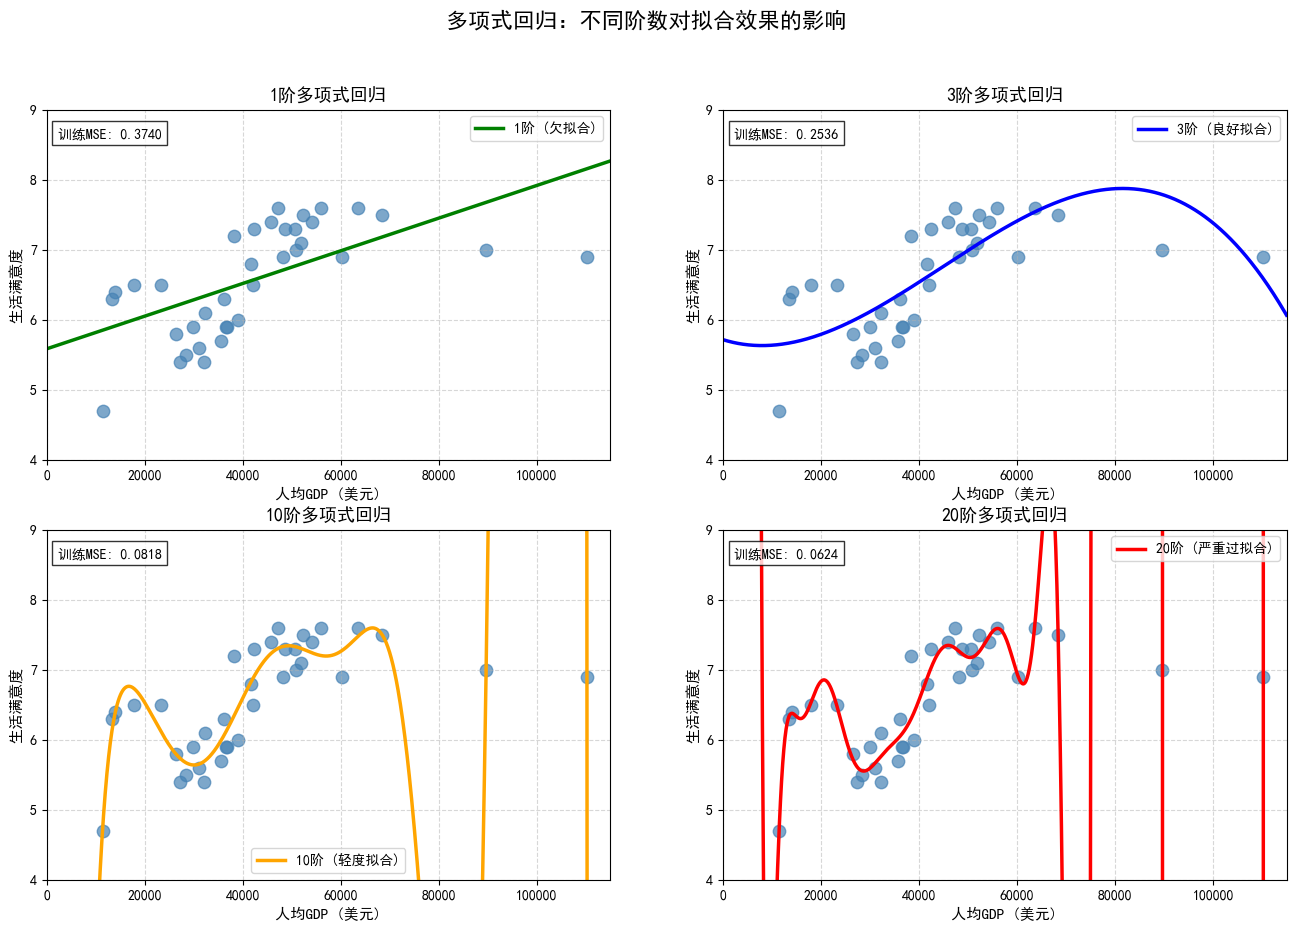

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn import preprocessing
from sklearn import pipeline
from sklearn import linear_model

# 设置中文字体 (解决中文显示问题)
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 定义保存图片的函数
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """保存图片到 images 文件夹"""
    path = os.path.join("images", fig_id + "." + fig_extension)
    os.makedirs("images", exist_ok=True)
    print(f"保存图片: {fig_id}")
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

print("="*70)
print("多项式回归：过拟合问题演示与解决方案")
print("="*70)

# 定义列名
gdppc_col = "GDP per capita (USD)"  # 人均GDP列名
lifesat_col = "Life satisfaction"   # 生活满意度列名

# 设置坐标轴范围
min_life_sat = 4     # 最小生活满意度
max_life_sat = 9     # 最大生活满意度

# 读取完整数据集
print("\n1. 读取完整数据集...")
try:
    full_country_stats = pd.read_csv(r'D:\python_demo\coding\data\machineLearningData\lifesat_full.csv', index_col=0)
    print(f"   数据集包含: {len(full_country_stats)} 个国家")
except FileNotFoundError:
    print("   警告：未找到 lifesat_full.csv，使用 lifesat.csv")
    full_country_stats = pd.read_csv(r'D:\python_demo\coding\data\machineLearningData\lifesat.csv')
# 准备数据
Xfull = np.c_[full_country_stats[gdppc_col]]   # 特征: 人均GDP
yfull = np.c_[full_country_stats[lifesat_col]] # 目标: 生活满意度

# 生成用于绘制曲线的X值
X = np.linspace(0, 115_000, 1000)

print("\n2, 对比不同复杂度的模型...")

# 创建图表 (注意：原代码此处有重复定义，建议保留下面这一组即可)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('多项式回归：不同阶数对拟合效果的影响', fontsize=16, fontweight='bold')

# 测试不同的多项式阶数
degrees = [1, 3, 10, 20]  # 线性、适中、过拟合、严重过拟合

for idx, degree in enumerate(degrees):
    ax = axes[idx // 2, idx % 2]
    
    # 绘制散点图
    full_country_stats.plot(kind='scatter', 
                            x=gdppc_col, 
                            y=lifesat_col, 
                            grid=True, 
                            color='steelblue',
                            s=80,
                            alpha=0.7,
                            ax=ax)
    print(f"\n  训练 {degree} 阶多项式模型...")

    # 创建多项式特征转换器
    poly = preprocessing.PolynomialFeatures(degree=degree, include_bias=False)
    
    # 创建标准化器
    scaler = preprocessing.StandardScaler()
    
    # 创建线性回归模型
    lin_reg = linear_model.LinearRegression()
    
    # 创建管道：多项式特征 -> 标准化 -> 线性回归
    pipeline_reg = pipeline.Pipeline([
        ('poly', poly),      # 步骤1：生成多项式特征
        ('scal', scaler),    # 步骤2：标准化特征
        ('lin', lin_reg)     # 步骤3：线性回归
    ])
    
    # 训练模型 (添加异常处理)
    try:
        pipeline_reg.fit(Xfull, yfull)  # 训练
        
        # 预测曲线
        curve = pipeline_reg.predict(X[:, np.newaxis])
        
        # 检查预测结果是否有效
        if np.any(np.isnan(curve)) or np.any(np.isinf(curve)):
            print(f"    警告：{degree}阶模型产生无效预测值，跳过")
            curve = np.full_like(curve, np.nan)
    except Exception as e:
        print(f"    错误：{degree}阶模型训练失败 - {str(e)[:50]}")
        curve = np.full_like(X, np.nan)
        mse = np.nan

    # 绘制预测曲线 (仅当曲线有效时)
    if degree == 1:
        color, label = 'green', f'{degree}阶 (欠拟合)'
    elif degree == 3:
        color, label = 'blue', f'{degree}阶 (良好拟合)'
    elif degree == 10:
        color, label = 'orange', f'{degree}阶 (轻度拟合)'
    else:
        color, label = 'red', f'{degree}阶 (严重过拟合)'
    
    # 只绘制有效曲线
    if not np.all(np.isnan(curve)):
        ax.plot(X, curve, color=color, linewidth=2.5, label=label)
    else:
        ax.text(0.5, 0.5, f'{degree}阶模型\n数值溢出', 
                transform=ax.transAxes, fontsize=14, color='red', 
                ha='center', va='center', 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 设置坐标轴范围
    ax.set_xlim(0, 115_000)
    ax.set_ylim(min_life_sat, max_life_sat)
    
    # 设置标签
    ax.set_xlabel('人均GDP (美元)', fontsize=11, fontweight='bold')
    ax.set_ylabel('生活满意度', fontsize=11, fontweight='bold')
    ax.set_title(f'{degree}阶多项式回归', fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

    # 计算并显示训练误差
    if not np.all(np.isnan(curve)):
        train_predictions = pipeline_reg.predict(Xfull)
        mse = np.mean((train_predictions - yfull) ** 2)  # 根据MSE公式
        ax.text(0.02, 0.92, f'训练MSE: {mse:.4f}', transform=ax.transAxes, fontsize=10, 
                bbox=dict(facecolor='white', alpha=0.8))

# 显示图表
plt.show()


解决过拟合的方法

方案1: 降低模型复杂度 (3阶多项式) 
方案2: 使用正则化 (Ridge回归) 
方案3: 简化特征 (早停法思想) 


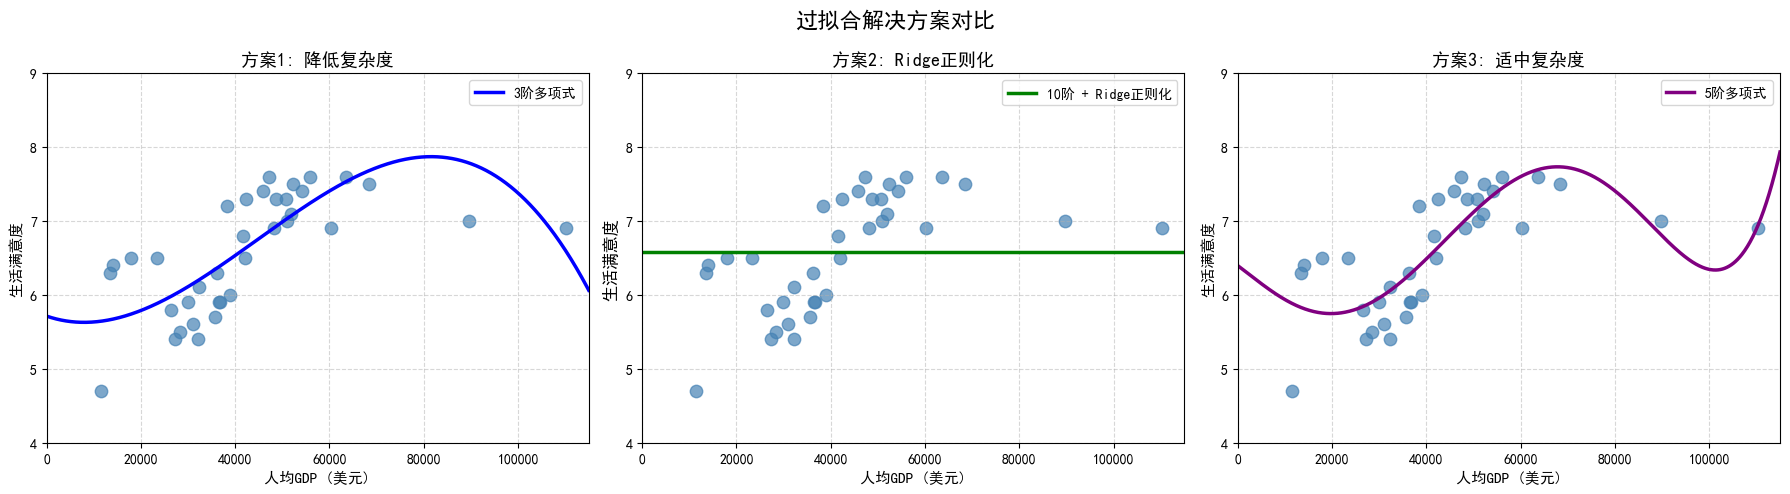


总结

过拟合的表现:
 - 模型在训练数据上表现完美, 但曲线过于复杂
 - 曲线剧烈波动, 试图完美拟合每个数据点
 - 在新数据上预测效果差 (泛化能力弱) 

解决过拟合的方法:
 1.降低模型复杂度
    - 减少多项式阶数
    - 使用更简单的模型

 2.正则化 (Regularization) 
    - Ridge回归 (L2正则化) 
    - Lasso回归 (L1正则化) 
    - 惩罚过大的参数值

 3.增加训练数据
    - 收集更多的样本
    - 数据增强

 4.交叉验证
    - K折交叉验证
    - 评估模型泛化能力

 5.早停法 (Early Stopping) 
    - 监控验证集性能
    - 及时停止训练

推荐做法: 
 - 从简单模型开始, 逐步增加复杂度
 - 使用交叉验证评估模型
 - 对比训练误差和验证误差
 - 选择泛化能力最好的模型


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# 假设上下文：Xfull, yfull, gdppc_col, lifesat_col, full_country_stats 等变量已在上一段代码中定义
# 如果没有定义，请确保将上一段代码的变量带入此处

print("\n" + "="*70)
print("解决过拟合的方法")
print("="*70)

# 创建新图表展示解决方案
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('过拟合解决方案对比', fontsize=16, fontweight='bold')

# ---------------------------------------------------------
# 方案1：降低模型复杂度（使用3阶多项式）
# ---------------------------------------------------------
print("\n方案1: 降低模型复杂度 (3阶多项式) ")
ax1 = axes[0]
full_country_stats.plot(kind='scatter', x=gdppc_col, y=lifesat_col,
                        grid=True, color='steelblue', s=80, alpha=0.7, ax=ax1)

poly3 = PolynomialFeatures(degree=3, include_bias=False)
scaler3 = StandardScaler()
lin_reg3 = linear_model.LinearRegression()
pipeline3 = Pipeline([('poly', poly3), ('scal', scaler3), ('lin', lin_reg3)])
pipeline3.fit(Xfull, yfull)
curve3 = pipeline3.predict(X=np.c_[np.linspace(0, 115000, 1000)]) # 重新生成X轴数据用于绘图

ax1.plot(np.linspace(0, 115000, 1000), curve3, 'b-', linewidth=2.5, label='3阶多项式')
ax1.set_xlim(0, 115_000)
ax1.set_ylim(min_life_sat, max_life_sat)
ax1.set_xlabel('人均GDP (美元)', fontsize=11, fontweight='bold')
ax1.set_ylabel('生活满意度', fontsize=11, fontweight='bold')
ax1.set_title('方案1: 降低复杂度', fontsize=13, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.5)


# ---------------------------------------------------------
# 方案2：正则化（Ridge回归，10阶多项式 + L2正则化）
# ---------------------------------------------------------
print("方案2: 使用正则化 (Ridge回归) ") # 修正拼写 Rigge -> Ridge
ax2 = axes[1]
full_country_stats.plot(kind='scatter', x=gdppc_col, y=lifesat_col,
                        grid=True, color='steelblue', s=80, alpha=0.7, ax=ax2)

poly10 = PolynomialFeatures(degree=10, include_bias=False)
scaler10 = StandardScaler()
# alpha 值越大，正则化越强，曲线越平滑
ridge_reg = linear_model.Ridge(alpha=10**9.5)  # L2正则化参数
pipeline_ridge = Pipeline([('poly', poly10), ('scal', scaler10), ('ridge', ridge_reg)])
pipeline_ridge.fit(Xfull, yfull)
curve_ridge = pipeline_ridge.predict(X=np.c_[np.linspace(0, 115000, 1000)])

ax2.plot(np.linspace(0, 115000, 1000), curve_ridge, 'g-', linewidth=2.5, label='10阶 + Ridge正则化')
ax2.set_xlim(0, 115_000)
ax2.set_ylim(min_life_sat, max_life_sat)
ax2.set_xlabel('人均GDP (美元)', fontsize=11, fontweight='bold')
ax2.set_ylabel('生活满意度', fontsize=12, fontweight='bold')
ax2.set_title('方案2: Ridge正则化', fontsize=13, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, linestyle='--', alpha=0.5)


# ---------------------------------------------------------
# 方案3：早停法 (模拟：使用较少的特征/中等复杂度)
# ---------------------------------------------------------
print("方案3: 简化特征 (早停法思想) ")
ax3 = axes[2]
full_country_stats.plot(kind='scatter', x=gdppc_col, y=lifesat_col,
                        grid=True, color='steelblue', s=80, alpha=0.7, ax=ax3)

poly5 = PolynomialFeatures(degree=5, include_bias=False)
scaler5 = StandardScaler()
lin_reg5 = linear_model.LinearRegression() # 调用模型
pipeline5 = Pipeline([('poly', poly5), ('scal', scaler5), ('lin', lin_reg5)])
pipeline5.fit(Xfull, yfull)
# 修正变量名拼写错误：pipline5 -> pipeline5
curve5 = pipeline5.predict(X=np.c_[np.linspace(0, 115000, 1000)]) 

ax3.plot(np.linspace(0, 115000, 1000), curve5, 'purple', linewidth=2.5, label='5阶多项式')
ax3.set_xlim(0, 115_000)
ax3.set_ylim(min_life_sat, max_life_sat)
ax3.set_xlabel('人均GDP (美元)', fontsize=11, fontweight='bold')
ax3.set_ylabel('生活满意度', fontsize=11, fontweight='bold')
ax3.set_title('方案3: 适中复杂度', fontsize=13, fontweight='bold')
ax3.legend(loc='best')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
# save_fig('overfitting_solutions') # 假设你有这个函数
plt.show()

print("\n"+"="*70)
print("总结")
print("="*70)
print("\n过拟合的表现:")
print(" - 模型在训练数据上表现完美, 但曲线过于复杂")
print(" - 曲线剧烈波动, 试图完美拟合每个数据点")
print(" - 在新数据上预测效果差 (泛化能力弱) ")

print("\n解决过拟合的方法:")
print(" 1.降低模型复杂度")
print("    - 减少多项式阶数")
print("    - 使用更简单的模型")
print("\n 2.正则化 (Regularization) ") # 修正拼写 Regularzation -> Regularization
print("    - Ridge回归 (L2正则化) ")
print("    - Lasso回归 (L1正则化) ")
print("    - 惩罚过大的参数值")
print("\n 3.增加训练数据")
print("    - 收集更多的样本")
print("    - 数据增强")
print("\n 4.交叉验证")
print("    - K折交叉验证")
print("    - 评估模型泛化能力")
print("\n 5.早停法 (Early Stopping) ")
print("    - 监控验证集性能")
print("    - 及时停止训练")

print("\n推荐做法: ")
print(" - 从简单模型开始, 逐步增加复杂度")
print(" - 使用交叉验证评估模型")
print(" - 对比训练误差和验证误差")
print(" - 选择泛化能力最好的模型")
print("="*70)

(10, 2)


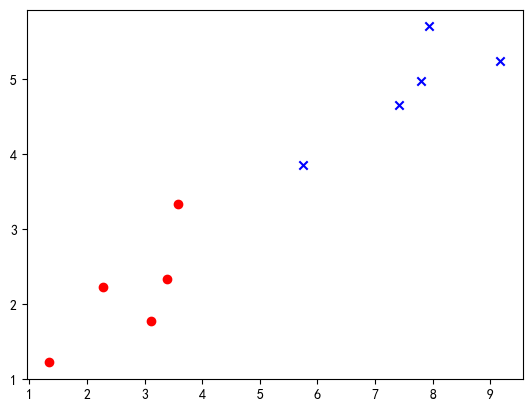

In [6]:
#数据处理
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
raw_data_x = [[3.3935, 2.3313],
            [3.1101, 1.7815],
            [1.3438, 1.2230],
            [3.5823, 3.3365],
            [2.2804, 2.2340],
            [7.4234, 4.6620],
            [5.7456, 3.8540],
            [9.1722, 5.2423],
            [7.7928, 4.9836],
            [7.9398, 5.7041]]
print(np.shape(raw_data_x))
raw_data_y = [0, 0, 0, 0, 0, 1, 1, 1, 1, 1]  #标签
X_train = np.array(raw_data_x)
y_train = np.array(raw_data_y)
#训练模型可视化
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0,1], color='red', marker='o', label='类别0')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1,1], color='blue', marker='x', label='类别1')
plt.show()

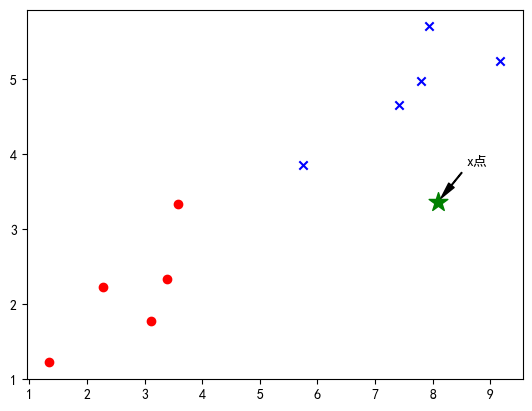

In [ ]:
#数据准备
#待预测点
X = np.array([8.0936, 3.3657])
fig, ax = plt.subplots()
#X_train[y_train==0][:, 0]表示取X_train中y_train等于0的行的第0列数据
ax.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][:,1], color='red', marker='o', label='类别0')
ax.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][:,1], color='blue', marker='x', label='类别1')
ax.scatter(X[0], X[1], color='green', marker='*', s=200, label='待预测点')
ax.annotate('x点', xy=(X[0], X[1]), xytext=(X[0]+0.5, X[1]+0.5),
            arrowprops=dict(facecolor='black', width=0.5, shrink=0.1, headwidth=5)#arrowprops箭头属性
            )
plt.show()

In [10]:
#距离计算
from math import sqrt 
distances = []
for x_ in X_train:
    d = sqrt(np.sum((X - x_)**2)) #计算欧氏距离, 两点间距离公式
    distances.append(d)
distances1 = [sqrt(np.sum((X - x_)**2)) for x_ in X_train] #计算欧氏距离，列表推导式
#查找距离索引
nearest_index = np.argsort(distances) #argsort返回的是排序后的索引
#设定K值，查找最近的K个邻
print("最近的K个邻居索引:", nearest_index)
k = 6
topK_y = [y_train[i] for i in nearest_index[:k]] #取出前K个样本的标签
topK_y

最近的K个邻居索引: [5 8 7 9 6 3 0 1 4 2]


[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0)]

In [ ]:
#统计投票表决
from collections import Counter #Counter计数器
vites=Counter(topK_y) #对标签进行计数
vites.most_common() #返回出现次数最多的标签及其次数, 默认按从大到小排序

[(np.int64(1), 5), (np.int64(0), 1)]

In [ ]:
#knn过程封装
def kNN_classify(k, X_train, y_train, x):
    """传入K的数量，训练集数据，训练集样本"""
    distances = [sqrt(np.sum((x - x_)**2)) for x_ in X_train] #计算欧氏距离
    nearest = np.argsort(distances) #计算距离索引
    topK_y = [y_train[i] for i in nearest[:k]] #取出前K个样本的标签
    votes = Counter(topK_y) #对标签进行计数
    return votes.most_common() #返回出现次数最多的标签

#封装检测
x = np.array([2.5, 2.5])
print(kNN_classify(3, X_train, y_train, x))


[(np.int64(0), 5), (np.int64(1), 1)]

## sklearn中的KNN回归模型

In [15]:
from sklearn.neighbors import KNeighborsClassifier
kNN_classify = KNeighborsClassifier(n_neighbors=6) #实例化kNN分类器
kNN_classify.fit(X_train, y_train) #训练模型

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [18]:
x1 = np.array([2.5, 2.5]).reshape(1, -1) #待预测点
kNN_classify.predict(x1) #预测训练的数据

array([0])

In [20]:
#knn添加具体算法，整合代码
import numpy as np
from math import sqrt
from collections import Counter
class KNNClassifier:
    def __init__(self, k=3):
        """初始化KNN分类器"""
        assert k>=1, "k must be valid"
        self.k = k
        self._X_train = None
        self._y_train = None
    def fit(self, X_train, y_train):
        """训练模型，存储训练数据"""
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        #验证数据有效性
        assert X_train.shape[0] == y_train.shape[0], \
        "X_train size must equal y_train size"
        assert self.k <= X_train.shape[0], \
        "k must not be larger than sample size"
        
        self._X_train = X_train
        self._y_train = y_train
        return self
    def predict(self, X_predict):
        """对待预测数据集进行分类"""
        #对assert表示断言，表示肯定一定
        assert self._X_train is not None and self._y_train is not None, \
        "must fit before predict!"
        #将输入转化为Numpy数组
        X_predict = np.array(X_predict)
        assert X_predict.shape[1] == self._X_train.shape[1], \
        "the feature number of X_predict must be equal to X_train"
        y_predict = [self._predict(x) for x in X_predict]
        return np.array(y_predict)
    def _predict(self, x):
        """给定单个待预测数据x，返回x的预测结果值"""
        assert x.shape[0] == self._X_train.shape[1], \
        "带预测样本x的特征数量必须与训练数据X_train的特征数量相同"
        #计算与所有训练数据的距离
        distances = [sqrt(np.sum((X_train - x)**2)) for x_train in self._X_train]
        nearest = np.argsort(distances) #距离排序
        topK_y = [self._y_train[i] for i in nearest[:self.k]]
        #投票决定最终类别
        votes = Counter(topK_y)
        return votes.most_common(1)[0][0]
    def __repr__(self):
        return "KNN(k=%d)" % self.k #使用示例

if __name__ == "__main__":
    #训练集 两类特征数据集
    X_train = [
        [1.2, 2.3], [1.8, 1.9], [2.5, 3.1], [3.6, 2.8], #类别
        [6.5, 7.2], [7.1, 6.8], [8.0, 7.5], [7.8, 8.3]
    ]
    #执行预测并输出结果
    y_train = [0, 0, 0, 0, 1, 1, 1, 1]  #标签
    #初始化KNN分类器
    knn_clf = KNNClassifier(k=3)
    knn_clf.fit(X_train, y_train) #训练模型
    x1 = np.array([2.0, 2.0]).reshape(1, -1) #待预测点
    print("预测结果:", knn_clf.predict(x1)) #预测训练的数据
    
    



预测结果: [0]


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt
from collections import Counter
from sklearn.model_selection import train_test_split #导入数据集划分模块
from sklearn.preprocessing import StandardScaler #导入数据标准化模块
from sklearn.metrics import classification_report, confusion_matrix
#加载数据
diamonds = sns.load_dataset('diamonds')
print(diamonds.head())
print(diamonds.isnull().sum()) #检查缺失值
#处理切工Fair=0, Good=1, Very Good=2, Premium=3, Ideal=4
diamonds['cut'] = diamonds['cut'].map({'Fair':0, 'Good':1, 'Very Good':2, 'Premium':3, 'Ideal':4})
#处理颜色D=6, J=0
diamonds['color'] = diamonds['color'].map({'D':6, 'E':5, 'F':4, 'G':3, 'H':2, 'I':1, 'J':0})
#处理净度IF=8, I1=0
diamonds['clarity'] = diamonds['clarity'].map({'IF':8, 'VVS1':7, 'VVS2':6, 'VS1':5, 'VS2':4, 'SI1':3, 'SI2':2, 'I1':0})
#X: 选取钻石的9个特征为输入变量(重量, 切工, 颜色, 净度, 长, 宽, 深, 深度百分比, 台宽百分比)
X = diamonds[['carat', 'cut', 'color', 'clarity', 'x', 'y', 'z']].values
#定义价格区间边界
#使用pd.qcut将文件分箱
try:
    diamonds['price_category'] = pd.qcut(diamonds['price'], q=3, labels=[0,1,2]) #qcut将数据分箱
except ValueError as e:
    print("警告: pd.qcut 失败，尝试使用 pd.cut 进行分箱 -", str(e))
    diamonds['price_category'] = pd.qcut(diamonds['price'], q=3, labels=[0,1,2], duplicates='drop') #处理重复边界值
if diamonds['price_category'].isnull().sum() > 0:
    print("警告: 价格分类中存在缺失值，尝试使用 pd.cut 进行分箱")
    diamonds = diamonds.dropna(subset=['price_category']) #删除缺失值
    #由于删除了部分行，需要重新定义价格区间边界
    X = diamonds[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']].values

#将目标变量转化为Numpy数组格式，方便以后的处理
y = diamonds['price_category'].values
price_ranges = pd.qcut(diamonds['price'], q=3, retbins=True)[1] #获取分箱边界
print("价格区间边界:")
for i in range(len(price_ranges)-1):
    print(f'类别 {i}: {price_ranges[i]:.2f} - {price_ranges[i+1]:.2f}')
#划分训练集和测试集
#tranin_test_split函数用于划分数据集, test_size表示测试集比例, random_state表示随机种子, stratify表示分层抽样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#特征标准化





price_bins = [diamonds['price'].min(),
              diamonds['price'].quantile(0.33),
              diamonds['price'].quantile(0.66),
              diamonds['price'].max()]
#将价格划分到三个区间并使用0,1,2表示
diamonds['price_category'] = pd.cut(diamonds['price'], bins=price_bins, labels=[0,1,2]) #cut将数据分箱
y = diamonds['price_category'].values
#划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#特征标准化
scaler = StandardScaler() #实例化标准化器
X_train_scaled = scaler.fit_trainsform(X_train) #训练并转换训练数据
X_test_scaled = scaler.transform(X_test)
#定义KNN分类器类
class KNNClassifier:
    def __init__(self, k=3):
        """初始化KNN分类器"""
        assert k>=1, "k must be valid" #assert断言
        self.k = k  #存储临近数1
        self._X_train = None
        self._y_train = None #存储训练集标签
    def fit(self,X_train, y_train):
        """训练模型，存储训练数据"""
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        #验证数据有效性
        assert X_train.shape[0] == y_train.shape[0], \
        "X_train size must equal y_train size"
        assert self.k <= X_train.shape[0], \
        "k must not be larger than sample size"
        self._X_train = X_train
        self._y_train = y_train                            
        return self #返回自身
    def predict(self, X_predict):
        """对待预测数据集进行分类"""
        #断言:必须先调用fit方法进行训练
        assert self._X_train is not None and self._y_train is not None, \
        "must fit before predict!"
        #将待与非数据转化为Numpy数组
        X_predict = np.array(X_predict)
        assert X_predict.shape[1] == self._X_train.shape[1], \
        "the feature number of X_predict must be equal to X_train"
        #欧式距离
        #向量计算距离：提高大型数据计算效率
        #np.newaxis增加一个维度， 表示
        distances = np.sqrt(np.sum((self._X_train[:, np.newaxis, :] - X_predict[np.newaxis, :, :])**2, axis=2))
        #对每个带一侧据计算预测结果
        y_predict = [self._predict_single(distances[:, i]) for i in range(X_predict.shape[0])]
        return np.array(y_predict)
    
    def _predict_single(self, distances):
        """预测单个样本的类别"""
        mearest_idx = np.argsort(distances)[:self.k] #距离排序
        topK_y = [self._y_train[nearest_index]]
        votes = Counter(topK_y) #投票决定最终类别
        return votes.most_common(1)[0][0]
    def __repr__(self):
        """自定义类的打印样式， 方便查看KNN的值"""
        return """KNN(k=%d)""" % self.k

#初始化并训练KNN模型
knn_clf = KNNClassifier(k=6)
knn_clf.fit(X_train, y_train)
#7.用测试集进行预测并评估模型性能
y_pred = knn_clf.predict(X_test_scaled) #对标准化后的模型进行训练
#输出分类报告和混淆矩阵
print("\n ====模型评估结果====")
y_pred, target_names = [X_test_scaled]
     

   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35  2.75
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64
价格区间边界:
类别 0: 326.00 - 1240.00
类别 1: 1240.00 - 4287.33
类别 2: 4287.33 - 18823.00

 ====模型评估结果====
              precision    recall  f1-score   support

          低价       0.98      0.97      0.98      3599
          中价       0.93      0.93      0.93      3593
          高价       0.95      0.96      0.95      3596

    accuracy                           0.95     10788
   macro avg       0.95      0.95      0.95     10788
weighted

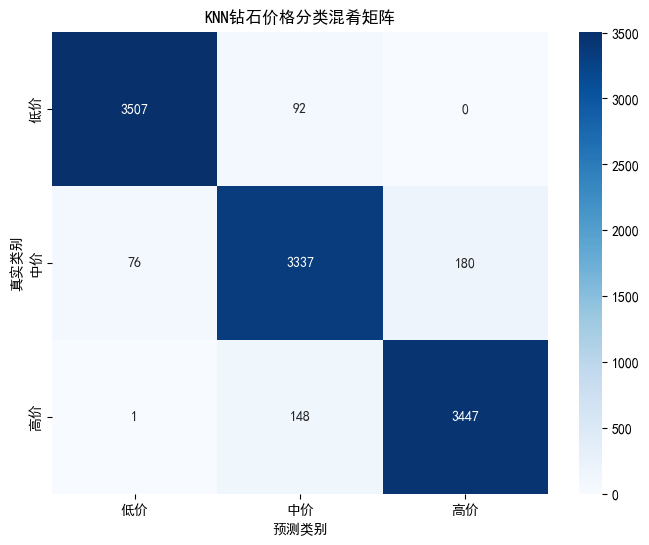


新钻石样本预测价格类别: 高价


In [6]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt
from collections import Counter
from sklearn.model_selection import train_test_split #导入数据集划分模块
from sklearn.preprocessing import StandardScaler #导入数据标准化模块
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier #导入KNN分类器
#加载数据
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
diamonds = sns.load_dataset('diamonds')
print(diamonds.head())
print(diamonds.isnull().sum()) #检查缺失值
#处理切工Fair=0, Good=1, Very Good=2, Premium=3, Ideal=4
diamonds['cut'] = diamonds['cut'].map({'Fair':0, 'Good':1, 'Very Good':2, 'Premium':3, 'Ideal':4})
#处理颜色D=6, J=0
diamonds['color'] = diamonds['color'].map({'D':6, 'E':5, 'F':4, 'G':3, 'H':2, 'I':1, 'J':0})
#处理净度IF=8, I1=0
diamonds['clarity'] = diamonds['clarity'].map({'IF':8, 'VVS1':7, 'VVS2':6, 'VS1':5, 'VS2':4, 'SI1':3, 'SI2':2, 'I1':0})
#X: 选取钻石的9个特征为输入变量(重量, 切工, 颜色, 净度, 长, 宽, 深, 深度百分比, 台宽百分比)
X = diamonds[['carat', 'cut', 'color', 'clarity', 'x', 'y', 'z']].values
#定义价格区间边界
#使用pd.qcut将文件分箱
try:
    diamonds['price_category'] = pd.qcut(diamonds['price'], q=3, labels=[0,1,2]) #qcut将数据分箱
except ValueError as e:
    print("警告: pd.qcut 失败，尝试使用 pd.cut 进行分箱 -", str(e))
    diamonds['price_category'] = pd.qcut(diamonds['price'], q=3, labels=[0,1,2], duplicates='drop') #处理重复边界值
if diamonds['price_category'].isnull().sum() > 0:
    print("警告: 价格分类中存在缺失值，尝试使用 pd.cut 进行分箱")
    diamonds = diamonds.dropna(subset=['price_category']) #删除缺失值
    #由于删除了部分行，需要重新定义价格区间边界
    X = diamonds[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']].values

#将目标变量转化为Numpy数组格式，方便以后的处理
y = diamonds['price_category'].values
price_ranges = pd.qcut(diamonds['price'], q=3, retbins=True)[1] #获取分箱边界
print("价格区间边界:")
for i in range(len(price_ranges)-1):
    print(f'类别 {i}: {price_ranges[i]:.2f} - {price_ranges[i+1]:.2f}')
#划分训练集和测试集
#tranin_test_split函数用于划分数据集, test_size表示测试集比例, random_state表示随机种子, stratify表示分层抽样
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#特征标准化
scaler = StandardScaler() #实例化标准化器
X_train_scaled = scaler.fit_transform(X_train) #训练并转换训练数据
X_test_scaled = scaler.transform(X_test)
#初始化并训练KNN模型
knn_clf = KNeighborsClassifier(n_neighbors=5, algorithm='auto') #初始化KNN分类器
#训练KNN模型
#fit方法接收训练集特征和标签
knn_clf.fit(X_train_scaled, y_train)
#用测试集进行预测，并评估模型性能
y_pred = knn_clf.predict(X_test_scaled)
#输出模型评估报告
print("\n ====模型评估结果====")
#classification_report函数用于生成分类报告, target_names用于指定类别名称
print(classification_report(y_test, y_pred, target_names=['低价', '中价', '高价']))
#绘制混淆助阵
plt.figure(figsize=(8,6))
#绘制真实标签和预测标签的混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['低价', '中价', '高价'], #x轴标签为预测类别
            yticklabels=['低价', '中价', '高价']) #y轴标签为真实类别
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('KNN钻石价格分类混肴矩阵')
plt.show()
#单个新样本预测示例
new_diamond = np.array([[1.0, 3, 4, 4, 62.0, 58.0, 6.4,]])
new_diamond_scaled = scaler.transform(new_diamond)
#使用训练好的模型对新样本进行预测
pred_category = knn_clf.predict(new_diamond_scaled)[0]
#创建一个映射字典，将类别数字映射回价格区间标签
price_map = {0: '低价', 1: '中价', 2: '高价'}
print(f"\n新钻石样本预测价格类别: {price_map[pred_category]}")


In [7]:
def train_test_split(X, y, test_size=0.2, seed=None):
    assert 0 < test_size < 1, \
    "验证集比例必须是0-1之间的数据"
    #seed表示随机种子， 保证数据划分结果可复现
    if seed:
        np.random.seed(seed)
    #表示打乱后的索引
    shuffle_indexes = np.random.permutation(len(X))
    #根据测试集比例计算测试集大小
    test_size = int(len(X) * test_size)
    test_indexes = shuffle_indexes[:test_size]
    train_indexes = shuffle_indexes[test_size:]
    #根据索引分别提取训练集和测试集特征与标签
    X_train = X[train_indexes]
    y_train = y[train_indexes]
    X_test = X[test_indexes]
    y_test = y[test_indexes]
    #返回划分后的训练集和测试集数据
    return X_train, X_test, y_train, y_test


## train_test_split()中的参数
该函数用于将数据集划分为训练集和测试集，常用参数包括：
- `test_size`：指定测试集所占比例或样本数，通常设置为0.2（20%）。
- `train_size`：指定训练集所占比例或样本数，通常与`test_size`互补。
- `random_state`：设置随机种子，确保每次划分结果一致。  
- `stratify`：用于分层抽样，确保训练集和测试集中各类别的比例与原始数据集相同，适用于分类任务。
- `shuffle`：是否在划分前打乱数据，默认为True。
- `return_indices`：是否返回划分后的索引，默认为False。
- `stratify=y`：表示根据标签`y`进行分层抽样，确保训练集和测试集中各类别的比例与原始数据集相同，适用于分类任务。
- `random_state=42`：设置随机种子为42，确保每次划分结果一致，便于结果复现。
- `test_size=0.2`：表示测试集占总数据集的20%，训练集占80%。
- `train_size`：未显式设置，默认为剩余部分，即80%。
- `shuffle=True`：表示在划分前打乱数据，增加数据的随机性，避免顺序对划分结果产生影响。
- `return_indices=False`：表示不返回划分后的索引，仅返回划分后的数据集。

In [ ]:
#sklearn的数据集分类
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=42,
                                                    test_size=0.2,)
X_train.shape

(43152, 7)